# Error Correction Model Parameter Estimation

The Error Correction for two $I(1)$ processes, $X_t$ and $Y_t$ the ECM is given by,

$
\begin{align}
\Delta Y_t = \gamma \Delta X_t + \lambda \left( Y_{t-1} - \beta X_{t-1} \right) + \nu_t
\end{align}
\tag{1}
$

where $\nu_t \sim \text{Normal}(0, \sigma^2)$.</br>

To perform parameter estimation let,

$
\begin{align}
\varepsilon_{t-1} = Y_{t-1} - \beta X_{t-1}
\end{align}
\tag{2}
$

OLS is used to used to estimate $\beta$ to obtain,

$
\begin{align}
\hat{\varepsilon}_{t-1} = Y_{t-1} - \hat{\beta} X_{t-1}
\end{align}
\tag{3}
$

where $\hat{\beta}$ is the OLS estimate of $\beta$. Next the ADF test is used to test $\hat{\varepsilon}_{t-1}$ for stationarity. Replacing the $Y_{t-1} - \beta X_{t-1}$ term in the ECM with $\hat{\varepsilon}_{t-1}$ gives

$
\begin{align}
\Delta Y_t = \gamma \Delta X_t + \lambda \hat{\varepsilon}_{t-1} + \nu_t
\end{align}
\tag{4}
$

Next $\gamma$ and $\lambda$ can be estimated using OLS. This is called the Granger two-step process.

In [9]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot
import statsmodels.api as sm

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import ecm, stats, adf, arima
from lib.plots import comparison, ecm_beta
from lib.utils import create_ensemble

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [10]:
def ecm_comparison_plot(xt, yt, φ, β, γ, λ, σ=1.0):
    title = f"ECM Simulation: φ={φ}, β={β}, γ={γ}, λ={λ}, σ={σ}"
    εt = yt - β * xt
    labels = [r"$x_t$", r"$y_t$", r"$\hat{\varepsilon}=y_t - \hat{\beta}x_t$"]
    comparison([xt, yt, εt], title=title, ylabel=r"$S_t$", xlabel=r"$t$", labels=labels, lw=1)

### $\beta$ Estimation

In [11]:
φ = 0.5
λ = -0.5
γ = 0.5
β = 0.5
npts = 1000

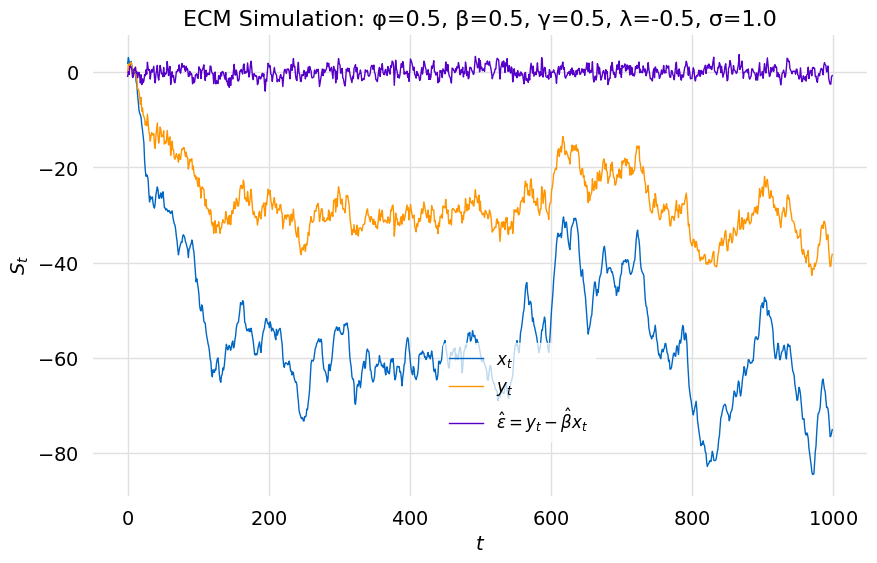

In [12]:
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

#### Residual Stationarity

In [13]:
εt = yt - β * xt
result, result_model = adf.compute_adf_test(εt)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -17.6777      │
├────────────────┼───────────────┤
│ pvalue         │   6.85747e-29 │
├────────────────┼───────────────┤
│ Lags           │   0           │
├────────────────┼───────────────┤
│ Number Obs     │ 999           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56798 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [14]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "test_id": "bc8d1fba-aeef-4360-a851-1a26e9255e16",
                "label": "$t$",
                "value": -17.677719111665997
            },
            "pval": {
                "test_id": "bc8d1fba-aeef-4360-a851-1a26e9255e16",
                "label": "$p-value$",
                "value": 6.857469098519403e-29
            },
            "params": [],
            "sig": {
                "test_id": "bc8d1fba-aeef-4360-a851-1a26e9255e16",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "bc8d1fba-aeef-4360-a851-1a26e9255e16",
                "label": "$t_L$",
                "value": -2.5679816723029334
            },
            "upper": null,
            "test_id": "bc8d1fba-aeef-4360-a851-1a26e9255e16"
        },
  

In [15]:
result, beta_result_model = ecm.compute_beta_estimate(yt, xt)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                 3.835e+04
Date:                Fri, 24 Nov 2023   Prob (F-statistic):               0.00
Time:                        14:36:33   Log-Likelihood:                -1578.6
No. Observations:                1000   AIC:                             3161.
Df Residuals:                     998   BIC:                             3171.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2751      0.144     -1.915      0.056      -0.557       0.007
x1             0.4954      0.003    195.842      0.000       0.490       0.500
==============================================================================
Omnibus:                        0.794   Durbin-Watson:                   0.957
Prob(Omnibus):                  0.672   Jarque-Bera (JB):                0.861
Skew:                           0.020   Prob(JB):                        0.650
Kurtosis:                       2.862   Cond. No.                         220.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [16]:
print(beta_result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": -0.27511915767253264,
      "err": 0.14364154510463487,
      "est_label": null,
      "err_label": null,
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "644d6176-2b3b-4843-9bc5-0130a6e92700",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": 0.49541629606219983,
         "err": 0.0025296723449343994,
         "est_label": null,
         "err_label": null,
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "644d6176-2b3b-4843-9bc5-0130a6e92700",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.9746392320579854,
   "param_transforms": [
      {
         "param": {
            "est": 0.49541629606219983,
            "err": 0.0025296723449343994,
            "est_label": "$\\hat{\\beta}$",
            "err_label": "$\\sigma_{\\hat{\\beta}}$",
            "row": 0,
            "column": 0,
            "order": 1,
            "est_id": "644d6176-2b3b-

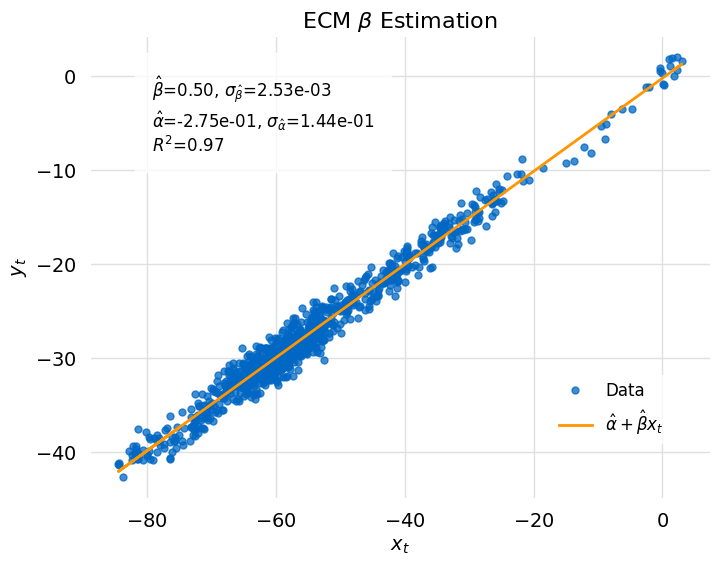

In [17]:
ecm_beta(yt, beta_result_model, xt)

### $\gamma$ and $\lambda$ Estimation

In [18]:
result, gamma_lambda_result_model = ecm.compute_gamma_lambda_estimate(yt, xt, beta_result_model.params[0].est)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.405
Model:                            OLS   Adj. R-squared:                  0.403
Method:                 Least Squares   F-statistic:                     338.3
Date:                Fri, 24 Nov 2023   Prob (F-statistic):          7.75e-113
Time:                        14:36:33   Log-Likelihood:                -1418.8
No. Observations:                 999   AIC:                             2844.
Df Residuals:                     996   BIC:                             2858.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1303      0.033     -3.987      0.000      -0.194      -0.066
x1             0.5083      0.028     18.199      0.000       0.453       0.563
x2            -0.4780      0.027    -17.655      0.000      -0.531      -0.425
==============================================================================
Omnibus:                        0.486   Durbin-Watson:                   2.009
Prob(Omnibus):                  0.784   Jarque-Bera (JB):                0.573
Skew:                           0.006   Prob(JB):                        0.751
Kurtosis:                       2.883   Cond. No.                         1.36
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [19]:
print(gamma_lambda_result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": -0.1303051355044204,
      "err": 0.03268063586795058,
      "est_label": null,
      "err_label": null,
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "6b735f70-c8f3-4c15-8ced-5b6a64d5cb64",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": 0.5082866064041589,
         "err": 0.02793003366623465,
         "est_label": null,
         "err_label": null,
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "6b735f70-c8f3-4c15-8ced-5b6a64d5cb64",
         "param_type": "OLS_PARAM"
      },
      {
         "est": -0.47795636368020106,
         "err": 0.027072182865013193,
         "est_label": null,
         "err_label": null,
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "6b735f70-c8f3-4c15-8ced-5b6a64d5cb64",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.40450516358431876,
   "param_transforms": [
      {
      